In [1]:
import numpy as np
import imageio.v3 as io
import matplotlib.pyplot as plt
import pandas as pd
from concurrent.futures import ThreadPoolExecutor

In [2]:
from lib.database import Database
from lib.domain import Feature, ImageRecord
from lib.features.haralick import HaralickFeatureExtractor
from lib.features.lbp import LBPFeatureExtractor

### Extração de features

In [3]:
def extract_features(img: np.ndarray) -> Feature:
    hal = HaralickFeatureExtractor.apply(img)
    lbp = LBPFeatureExtractor.apply(img)
    
    return np.concatenate((hal, lbp))

In [4]:
# DB para as features
db = Database()

df = pd.read_csv("./data/metadata.csv")
df.head()

,class_id,class_name,filename
0,0,simba,simba/00000.jpg
1,0,simba,simba/00001.jpg
2,0,simba,simba/00002.jpg
3,0,simba,simba/00003.jpg
4,0,simba,simba/00004.jpg


In [5]:
def worker(r: pd.Series) -> ImageRecord:
    img = io.imread(f"./data/{r["filename"]}")
    features = extract_features(img)
    
    return ImageRecord(
        r["class_name"],
        r["filename"],
        features
    )
    
with ThreadPoolExecutor(max_workers=5) as ex:
    results = ex.map(worker, [row for index, row in df.iterrows()])
    for result in results:
        db.insert(result)
    
   

### Busca

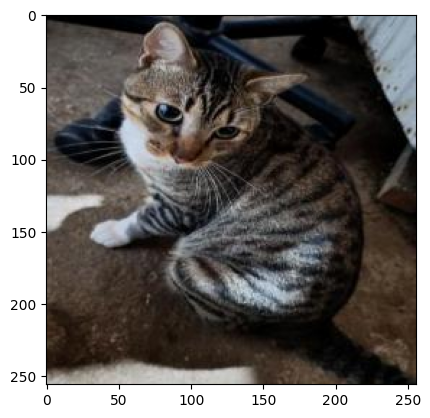

In [6]:
# Imagem para buscar
target = io.imread("./data/simba/00000.jpg")
vec = extract_features(target)
plt.imshow(target)

In [7]:
results = db.search(vec)

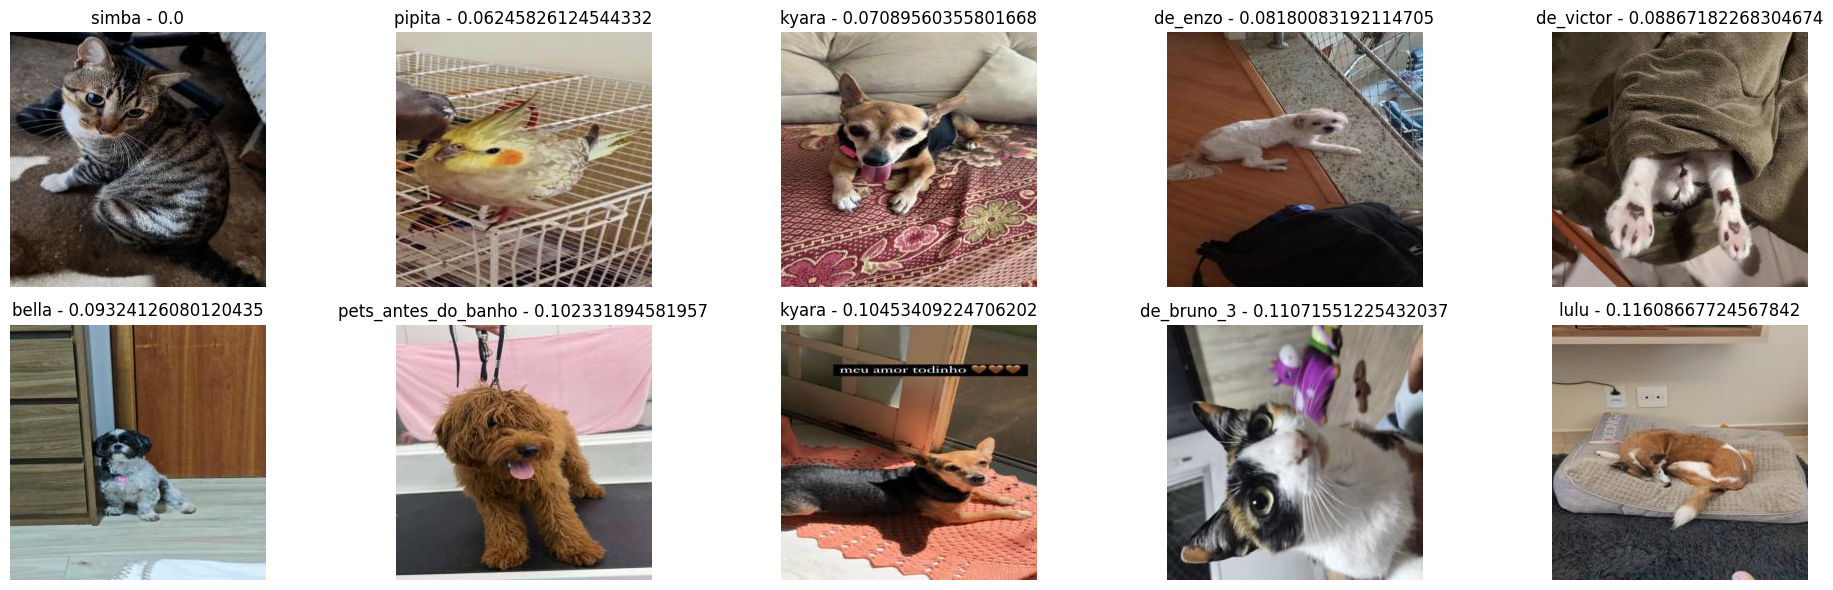

In [8]:
# Exibir imagem buscada e os resultados encontreados
# (já estão ordenados por distancia)
fig, axes = plt.subplots(2, 5, figsize=(20, 6))
axes = axes.flatten()

for ax, res in zip(axes, results):

    img = io.imread(f"./data/{res.url}")

    ax.imshow(img, cmap="gray")
    ax.set_title(f"{res.name} - {res.distance}")
    ax.axis("off")

plt.tight_layout()
plt.show()